In [1]:
import numpy as np
import pandas as pd
import pyproj
import verde as vd
import harmonica as hm
import matplotlib.pyplot as plt 
import bordado as bd

import spherical as sph
import eqs_magnetics as eqs

In [12]:
def generate_spherical_checkerboard_sample(
    region, size, amplitude, w_longitude=None, w_latitude=None, random_seed=None
):

    coordinates = bd.random_coordinates_spherical(
        region, size, random_seed=random_seed, non_dimensional_coords=None
    )
    longitude, latitude = coordinates[0], coordinates[1]
    
    
    if w_longitude is None:
        w_longitude = (region[1] - region[0]) / 8  
        if w_longitude == 0: 
            w_longitude = 1 
    if w_latitude is None:
        w_latitude = (region[3] - region[2]) / 6 
        if w_latitude == 0: 
            w_latitude = 1

    data = (
        amplitude
        * np.sin((2 * np.pi / w_longitude) * longitude)
        * np.cos((2 * np.pi / w_latitude) * latitude)
    )
    
    results = pd.DataFrame({
        'Longitude': longitude,
        'Latitude': latitude,
        'Scalar_Value': data.round(2)
    })
    return results


In [13]:
# region_geo = [-180, 180, -90, 90]


# synth = vd.synthetic.CheckerBoard(
#     amplitude=150,
#     region=region_geo,
#     w_east=None,
#     w_north=None,
# )

# table = synth.scatter(
#     size=5000,       
#     random_state=42, 
# )

# df = pd.DataFrame({
#     "longitude": table["easting"].values, 
#     "latitude": table["northing"].values,
#     "height": 300 * np.ones_like(table["easting"].values),
#     "TFA": table["scalars"].values,
# })

# coordinates = df["longitude"], df["latitude"], df["height"]

# print(df)

region_geo = [-180, 180, -90, 90]
NUM_POINTS = 5000
AMPLITUDE = 150
SEED = 42
HEIGHT_VALUE = 300.0


table = generate_spherical_checkerboard_sample(
    region=region_geo, 
    size=NUM_POINTS, 
    amplitude=AMPLITUDE,
    w_longitude=None, 
    w_latitude=None,  
    random_seed=SEED
)

df = pd.DataFrame({
    "longitude": table["Longitude"].values, 
    "latitude": table["Latitude"].values,
    "height": HEIGHT_VALUE * np.ones_like(table["Longitude"].values),
    "TFA": table["Scalar_Value"].values,
})

coordinates = df["longitude"], df["latitude"], df["height"]


# Projected equivalent-sources

In [14]:
proj_merc = pyproj.Proj(proj="merc", lat_ts=np.mean(df["latitude"]))
easting, northing = proj_merc(df["longitude"], df["latitude"])


region_sph = vd.get_region((df["longitude"], df["latitude"]))
region_cart = vd.get_region((easting, northing))

coordinates_projected = easting, northing, df["height"]

inclination, declination = 45, 20

field_direction = np.array([hm.magnetic_angles_to_vec(1, inclination, declination)]).T

In [15]:
eqs_projected = eqs.EquivalentSourcesMagnetic(damping=10, depth=1000e3)
eqs_projected.fit(coordinates_projected, df["TFA"], field_direction)

projected_obs = hm.total_field_anomaly(eqs_projected.predict(coordinates_projected), inclination=inclination, declination=declination)

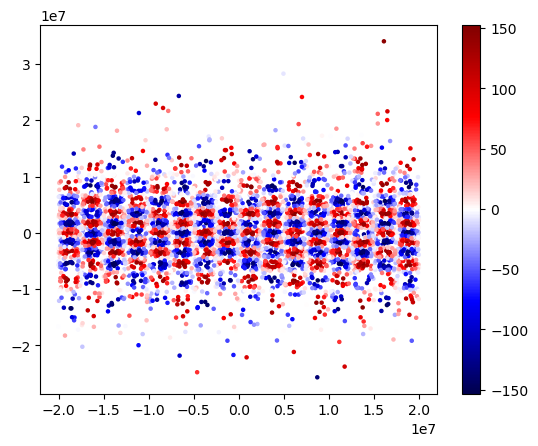

In [16]:
c = plt.scatter(
    coordinates_projected[0], coordinates_projected[1],
    c=projected_obs, s=5, cmap="seismic"
)

plt.colorbar(c)

In [17]:
grid_coords_cart = bd.grid_coordinates(region=region_cart, spacing=55e3, non_dimensional_coords=500)

projected_grid =  hm.total_field_anomaly(eqs_projected.predict(grid_coords_cart), inclination=inclination, declination=declination)

# Spherical equivalent-sources 

In [18]:
eqs_spherical = sph.EquivalentSourcesMagGeod(damping=10, depth=1000e3)

eqs_spherical.fit(coordinates, inclination, declination, df["TFA"].values)

spherical_obs = hm.total_field_anomaly(eqs_spherical.predict(coordinates), inclination=inclination, declination=declination)

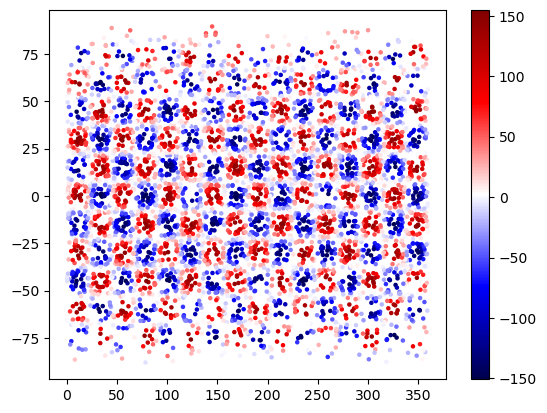

In [19]:
c= plt.scatter(
    coordinates[0], coordinates[1],
    c=spherical_obs, s=5, cmap="seismic"
)

plt.colorbar(c)

In [10]:
grid_coords_sph = bd.grid_coordinates(region=region_sph, spacing=0.5, non_dimensional_coords=500) # a cada 1km 0.009

spherical_grid =  hm.total_field_anomaly(eqs_spherical.predict(grid_coords_sph), inclination=inclination, declination=declination)

## Projected grid vs spherical grid

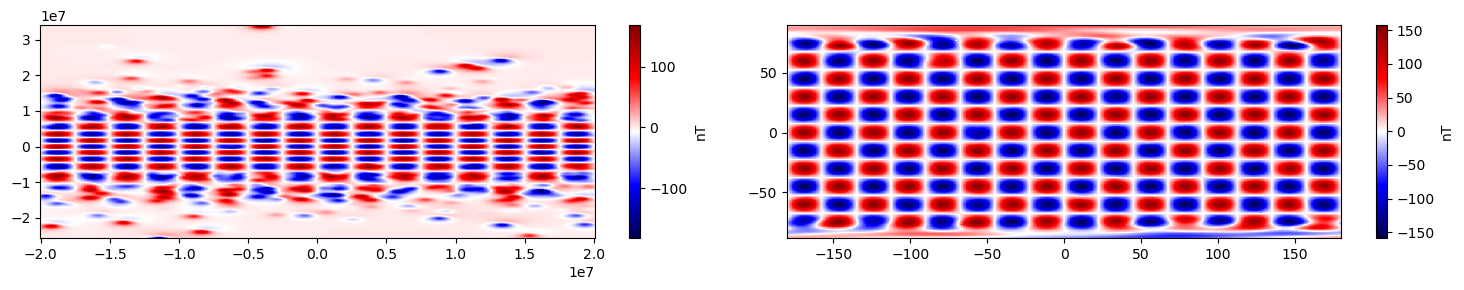

In [11]:
plt.figure(figsize=(15,3))

plt.subplot(1,2,1)
plt.pcolormesh(
    *grid_coords_cart[:2], projected_grid, cmap="seismic"
)
plt.colorbar(label='nT')


plt.subplot(1,2,2)
plt.pcolormesh(
    *grid_coords_sph[:2], spherical_grid, cmap="seismic"
)
plt.colorbar(label='nT')
plt.tight_layout()